# KNN from Scratch

**knn.py** file where KNN is implemented from scratch
```
import numpy as np
from collections import Counter

def euclidean_distance(x1, x2):
    """
    :param x1: New Data Point
    :param x2: Data Points in dataset
    :return: Distance between new data point and all data points in
    training set
    """
    distance = np.sqrt(np.sum((x1-x2)**2))
    return distance

# def euclidean_distance(x1, x2):
#     """
#     :param x1: New Data Point
#     :param x2: Data Points in dataset
#     :return: Distance between new data point and all data points in
#     training set
#     """
#     distance = np.linalg.norm(x1 - x2)
#     return distance

class KNN:
    """
    KNN Class for implementing KNN Algorithm in Scikit-learn style
    """
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        """
        :param X: Feature Vector
        :param y: Class Label
        Sets the value of X_train and y_train.
        """

        self.X_train = X
        self.y_train = y

    def predict(self, X):
        """
        :param X: Datapoints for which prediction have to be made
        :return: Prediction for given datapoints
        """
        predictions = [self._predict(x) for x in X]
        return predictions

    def _predict(self, x):
        """
        Helper function that carries out actual prediction
        :param X: Datapoint for which prediction have to be made
        :return: Prediction for given datapoint
        """
        # compute the distance
        distances = [euclidean_distance(x, x_train) for x_train in self.X_train]

        # get the closest k
        k_indices = np.argsort(distances)[:self.k]
        # get First K labels
        k_nearest_labels = [self.y_train[i] for i in k_indices]

        # majority vote
        most_common = Counter(k_nearest_labels).most_common()
        return most_common[0][0]
```

## Import the Required Libraries

In [1]:
# Import the Required Libraries
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn import datasets
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from knn import KNN

## Iris Dataset

In [2]:
iris = datasets.load_iris()
X, y = iris.data, iris.target

## Plot to Visualize Different Classes

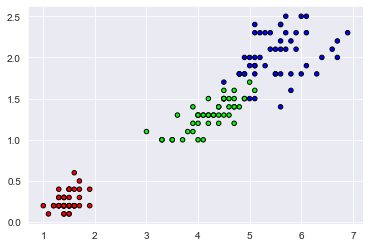

In [3]:
cmap = ListedColormap(['#FF0000','#00FF00','#0000FF'])
plt.figure()
plt.scatter(X[:,2],X[:,3], c=y, cmap=cmap, edgecolor='k', s=20)
plt.show()

## Train Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

## Create the Model

In [5]:
clf = KNN(k=5)

## Train the Model

In [6]:
clf.fit(X_train, y_train)

## Make the Prediction

In [7]:
predictions = clf.predict(X_test)

## Get Accuracy

In [8]:
acc = np.sum(predictions == y_test) / len(y_test)
print("{:.2f}".format(acc))

0.97


## Make Prediction for New Data Point

In [9]:
clf.predict([[5.8, 2.8, 5.1, 2.4]])

[2]

In [10]:
from sklearn.metrics import accuracy_score

In [11]:
acc = accuracy_score(y_true=y_test,y_pred=predictions)
print("{:.2f}".format(acc))

0.97


## Use Scikit-Learn

In [12]:
from sklearn.neighbors import KNeighborsClassifier
clf_sci = KNeighborsClassifier(n_neighbors=5,p=2)
clf_sci.fit(X_train,y_train)
sci_pred = clf_sci.predict(X_test)
acc_sci = accuracy_score(y_true=y_test,y_pred=sci_pred)
print("{:.2f}".format(acc_sci))

0.97


# MNIST Handwritten Digit Dataset

In [13]:
# Load the MNIST dataset
mnist = fetch_openml('mnist_784')

In [14]:
# Access the images
images = mnist['data']
# Access the labels
labels = mnist['target']

## Example of Each Digit 

In [15]:
images=images.values

# Reshape the images to 28x28
images = images.reshape(-1, 28, 28)

# Create a dictionary to store the example images
examples = {}

# Iterate over the images and labels
for i in range(len(images)):
    label = labels[i]
    image = images[i]
    # If the label is not already in the examples dictionary
    if label not in examples:
        examples[label] = image

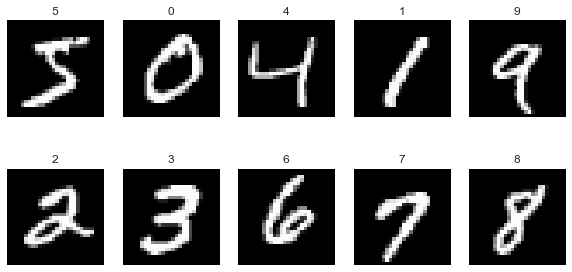

In [16]:
# Plot the example images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.ravel()
for i, (label, image) in enumerate(examples.items()):
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(label)
    axes[i].axis('off')
plt.show()

## Train Test Split

In [17]:
X = mnist['data'][:1500]
y = mnist['target'][:1500]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [18]:
X.shape

(1500, 784)

## Create and Train the Model

In [19]:
d_clf = KNN(k=5)
d_clf.fit(X_train.values,y_train.values)

## Make Prediction on Testset

In [20]:
pred = d_clf.predict(X_test.values)

## Get Accuracy

In [27]:
accuracy_score(pred,y_test)

0.8733333333333333

## Making Prediction on New Image

### Function to Load and Preprocess Image

In [28]:
import cv2
def pre_process_image(file_path):
    test_image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
    # Format Image
    img_resized = cv2.resize(test_image, (28, 28), interpolation=cv2.INTER_LINEAR)
    img_resized = cv2.bitwise_not(img_resized)
    # Convert the image data to a numpy array
    img_data = np.array(img_resized)
    # Reshape the image data to a 1-D array
    img_data = img_data.reshape(-1)
    return img_data

In [30]:
image_files = ['images/4_image.jpg','images/4_image_1.jpg','images/5_image.jpg']
for item in image_files:
    img_data = pre_process_image(item)
    pred = d_clf.predict([img_data])
    print(f"The Prediction for {item} is {pred}")

The Prediction for images/4_image.jpg is ['8']
The Prediction for images/4_image_1.jpg is ['2']
The Prediction for images/5_image.jpg is ['8']


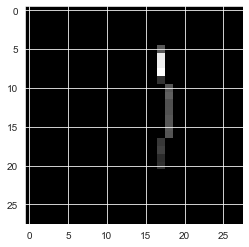

In [33]:
import cv2 
# Load sample image
file = r'images/1_img.PNG'
test_image = cv2.imread(file, cv2.IMREAD_GRAYSCALE)
# Format Image
img_resized = cv2.resize(test_image, (28, 28), interpolation=cv2.INTER_LINEAR)
# img_resized = cv2.bitwise_not(img_resized)
# Preview reformatted image
plt.imshow(img_resized, cmap='gray')

In [34]:
# Convert the image data to a numpy array
img_data = np.array(img_resized)
# Reshape the image data to a 1-D array
img_data = img_data.reshape(-1)

In [35]:
d_clf.predict([img_data])

['1']